# Forecasting the Future: ARIMA, SARIMA, and Serving Models with FastAPI

**Format:** interactive. When you see a 🎯 **Your turn** block, post your answer in the chat.
Wrong answers are welcome — they are the fastest way to learn.

## Agenda

1. Why forecasting matters
2. Anatomy of a time series, and stationarity
3. AR, MA, and ARMA — the building blocks
4. ARIMA in practice: picking p, d, q
5. SARIMA: handling seasonality
6. From notebook to production: FastAPI

---

## 1. Why forecasting matters

Every company runs on guesses about the future:

- **Uber** forecasts ride demand per city block to position drivers *before* the surge.
- **Walmart** forecasts sales per product per store to decide what goes on trucks tonight.
- **Power grids** forecast electricity demand hourly. A bad forecast means blackouts or wasted fuel.
- **Airlines** forecast passenger demand to plan aircraft, crew, and fuel months ahead.

Today **you are the data team at an airline in 1960**. The board wants to know:
*how many passengers will fly with us next year?* Buy too many planes and the company
bleeds cash. Buy too few and competitors take the customers.

Your dataset: monthly international passenger counts, 1949–1960. Let's look at it.

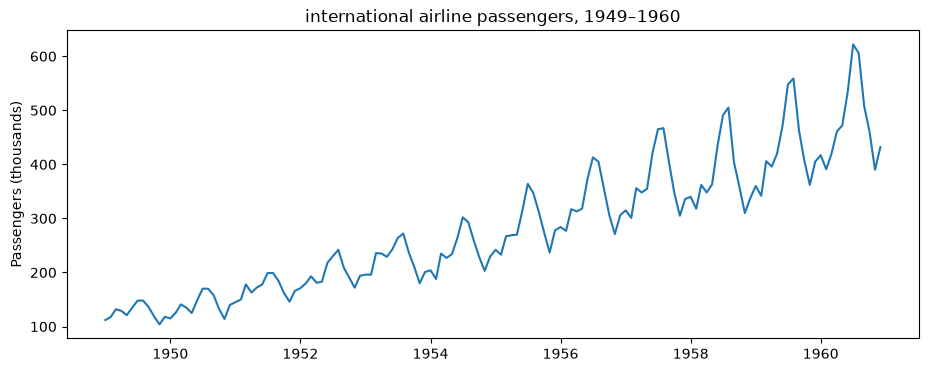

In [4]:
import warnings
warnings.filterwarnings("ignore")  # keep output clean for the session

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# One color per "thing", used consistently in every chart
C_OBS = "#1f77b4"    # observed data  (blue)
C_ARIMA = "#ff7f0e"  # ARIMA forecast (orange)
C_SARIMA = "#9467bd" # SARIMA forecast (purple)

df = pd.read_csv("airline_passengers.csv", parse_dates=["Month"], index_col="Month")
y = df["Passengers"].asfreq("MS")  # MS = "month start" frequency

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y, color=C_OBS)
ax.set_title("international airline passengers, 1949–1960")
ax.set_ylabel("Passengers (thousands)")
plt.show()

my great grandfather's yearly income

**The fix is differencing:** stop modeling the *values* and model the
**month-to-month change** instead:

construction engineer

slary/month

1921 => 50$ 
1922 => 53$
1923 => 55$
1924 => 58$
1925 => 65$

1922 => 3$
1923 => 2$
1924 => 3$
1925 => 7$
convert this into % -> mean%

2026 => 7000$
2027 => 

🎯 **Your turn (chat):** Look at the plot for 20 seconds. Name **three patterns** you see.

<details><summary>Reveal (click after the discussion)</summary>

1. **Trend** — passengers grow year after year.
2. **Seasonality** — the same peak (summer) and dip (winter) repeat every 12 months.
3. **Growing swings** — the seasonal ups and downs get *bigger* as the level grows.

Keep these three in mind. Each one maps to a specific tool we will use today.
</details>

We can ask pandas to separate these ingredients for us:

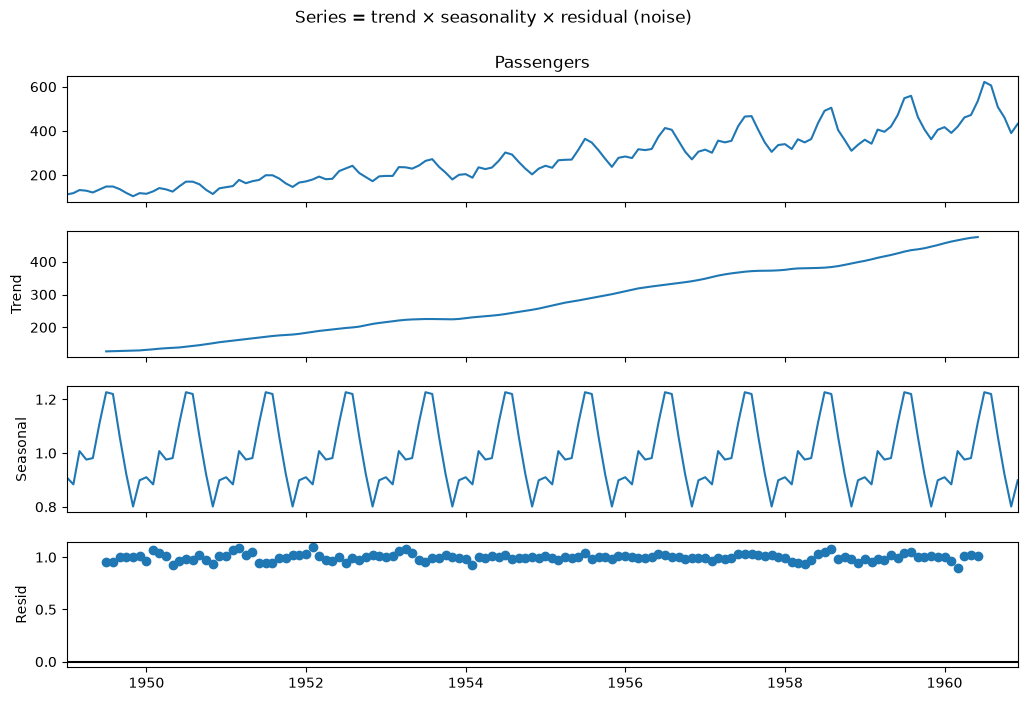

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

dec = seasonal_decompose(y, model="multiplicative")
fig = dec.plot()
fig.set_size_inches(11, 7)
fig.suptitle("Series = trend × seasonality × residual (noise)", y=1.02)
plt.show()

---

## 2. Stationarity: the rule models need

First, a trap to avoid: **stationary does *not* mean "the values don't change."**
A stationary series can wiggle constantly.

**Stationary means the *rules* of the series don't change over time:**

1. the average level stays the same, and
2. the typical size of the wiggles stays the same.

### The "cover the dates" test

Hide the x-axis labels and look at a random window of the series. **Can you tell
*when* it's from?**

- **Daily coin flips** (count of heads per day): a window from 1950 looks identical
  to a window from 1960. You cannot tell when it's from.
  → **stationary** — even though the values change every single day.
- **Our airline data**: values near 130? Must be 1949. Values near 480? Must be
  1960. The date is written into the values themselves.
  → **not stationary** — the average level keeps climbing.

One-liner to remember: *stationary means the **pattern** of change doesn't change.*

### Why models care

A model learns rules from the past and applies them to the future. If "the average"
keeps drifting upward, the rules it learned from 1949 are already wrong by 1960 —
it's studying for the wrong exam.

**The test:** the Augmented Dickey-Fuller (ADF) test puts a number on what our eyes
see. Small p-value (< 0.05) → stationary. Large p-value → not stationary.

🎯 **Predict before we run it:** what will the verdict be for the raw passenger data?

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    p = adfuller(series.dropna())[1]
    verdict = "stationary ✅" if p < 0.05 else "NOT stationary ❌"
    print(f"{name:<35s} p-value = {p:.4f}  →  {verdict}")

adf_report(y, "Raw passengers")

Raw passengers                      p-value = 0.9919  →  NOT stationary ❌


The test agrees with our eyes: the 1949 average is ~130 but the 1960 average is ~480, so
the mean depends on time — the "rules" keep changing. Not stationary.

**The fix is differencing:** stop modeling the *values* and model the
**month-to-month change** instead:

```
diff[t] = y[t] − y[t−1]
```

Watch what that does to the first four months of our data:

```
values:   112    118    132    129   ...   → climbs forever  (not stationary)
changes:      +6    +14     −3       ...   → hovers near 0   (stable rules!)
```

Whether passengers are at level 120 or level 450, the monthly *change* is a modest
number near zero — the level cancels out in the subtraction.

Everyday analogy: your **salary** grows across your whole career (not stationary),
but your **annual raise** is roughly stable year after year (stationary). Same
information, better behaved. Model the raises, not the salary.

Differencing once usually removes a trend. This is exactly the **I** in AR**I**MA
("Integrated"): ARIMA = difference the data, then model the changes.

After 1st difference                p-value = 0.0542  →  NOT stationary ❌
After 1st + seasonal difference     p-value = 0.0000  →  stationary ✅


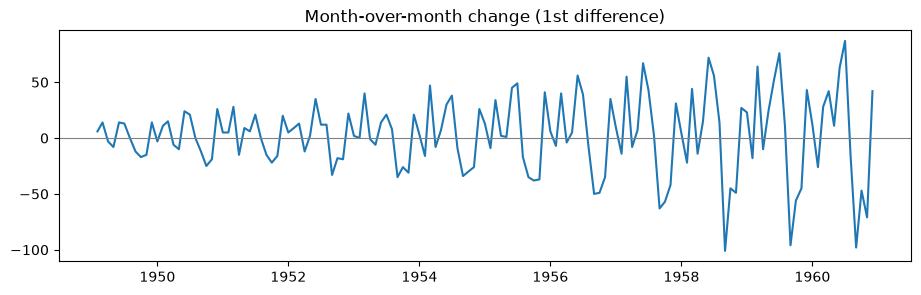

In [8]:
adf_report(y.diff(), "After 1st difference")
adf_report(y.diff().diff(12), "After 1st + seasonal difference")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(y.diff(), color=C_OBS)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Month-over-month change (1st difference)")
plt.show()

After 1st difference                p-value = 0.0542  →  NOT stationary ❌
After 1st + seasonal difference     p-value = 0.0000  →  stationary ✅


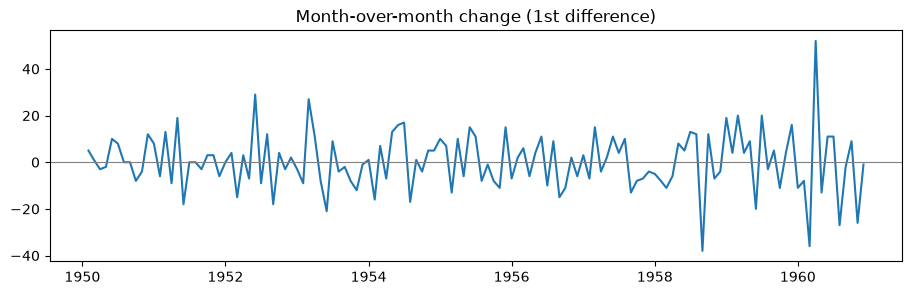

In [9]:
adf_report(y.diff(), "After 1st difference")
adf_report(y.diff().diff(12), "After 1st + seasonal difference")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(y.diff().diff(12), color=C_OBS)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Month-over-month change (1st difference)")
plt.show()

In [10]:
1 year = 100 -> 10%
year 2
year 3
year 4 so on

10% -> constant

SyntaxError: invalid syntax (172385792.py, line 1)

Apply the "cover the dates" test to this new plot: the line now hugs zero on the
left half *and* the right half — the climb is gone. That's why the p-value crashed
from 0.99 toward 0.05.

But it lands at p ≈ 0.05 — *borderline*, still technically failing. Look closely
and you can see why: a repeating **12-month rhythm** survives, and the swings still
grow over time. You *can* still roughly guess the date from the wiggle size.
**Seasonality is a form of non-stationarity too.** Remember this — it comes back
when we meet SARIMA.

---

## 3. The building blocks: AR, MA, ARMA

### AR — AutoRegressive: "today depends on yesterday"

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$$

Today's value is a **weighted blend of the last `p` values**, plus random noise.
The weight φ (phi) controls how much *memory* the series has.

Real-world AR behavior:
- **Temperature** — a hot day is usually followed by a hot day.
- **Warehouse stock levels** — today's stock is yesterday's stock plus small changes.
- **Server CPU load** — load decays gradually, it doesn't teleport.

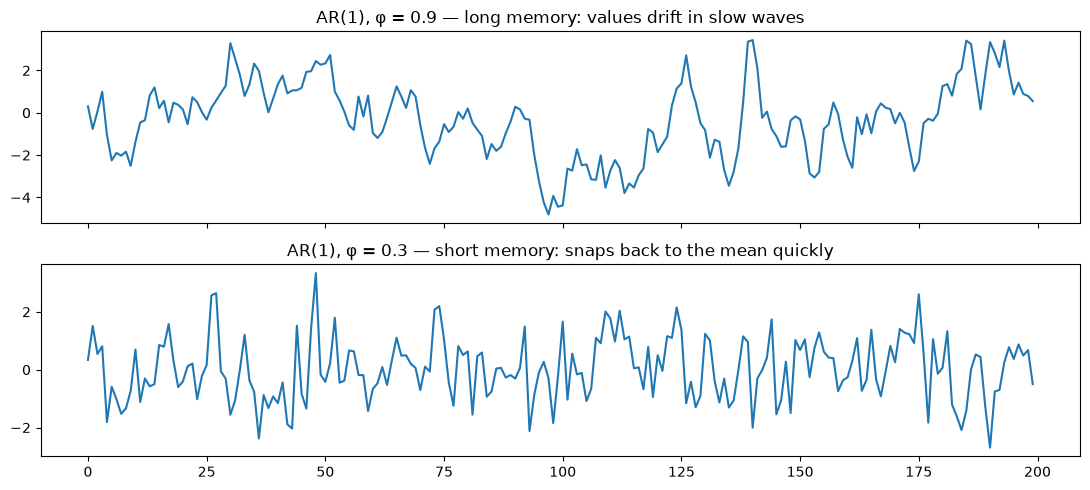

In [11]:
from statsmodels.tsa.arima_process import ArmaProcess

rng = np.random.default_rng(42)
ar_strong = ArmaProcess(ar=[1, -0.9]).generate_sample(200, distrvs=rng.standard_normal)
ar_weak   = ArmaProcess(ar=[1, -0.3]).generate_sample(200, distrvs=rng.standard_normal)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(ar_strong, color=C_OBS); axes[0].set_title("AR(1), φ = 0.9 — long memory: values drift in slow waves")
axes[1].plot(ar_weak, color=C_OBS);   axes[1].set_title("AR(1), φ = 0.3 — short memory: snaps back to the mean quickly")
plt.tight_layout(); plt.show()

### MA — Moving Average: "today echoes recent *surprises*"

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

Careful — the name is misleading. This is **not** a rolling average. An MA model says:
today = fresh random shock + **echoes of the last `q` shocks**. After `q` periods,
a shock is fully forgotten.

Real-world MA behavior:
- A **one-day factory power cut** hurts output for the next couple of days, then it's over.
- A **viral tweet** spikes your web traffic; the spike fades within days.
- A **supplier delay** ripples through this week's deliveries, then normality returns.

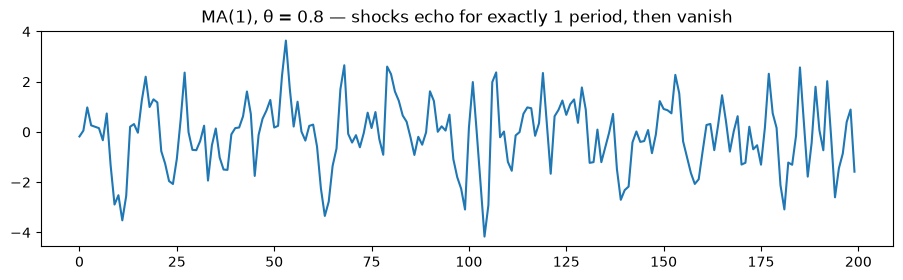

In [12]:
ma1 = ArmaProcess(ma=[1, 0.8]).generate_sample(200, distrvs=rng.standard_normal)

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(ma1, color=C_OBS)
ax.set_title("MA(1), θ = 0.8 — shocks echo for exactly 1 period, then vanish")
plt.show()

### ARMA(p, q) — both at once

Most real series have *some* memory (AR) **and** react to *some* shocks (MA), so we
combine them: **ARMA(p, q)** = AR(p) + MA(q).

---

🎯 **Your turn — quick-fire round (chat):** For each scenario, type **AR** or **MA**:

1. A hotel sets today's room price by adjusting *yesterday's price* up or down.
2. A factory has a one-day power cut. Output is low for two days, then fully back to normal.
3. Daily average temperature in your city.
4. Your bank balance: today = yesterday + a random deposit/withdrawal.

<details><summary>Answers</summary>

1. **AR** — today's value is built from yesterday's *value*.
2. **MA** — a *shock* that echoes for a fixed number of periods, then disappears.
3. **AR** — strong memory of recent values.
4. **AR with φ = 1** — a *random walk*. Trick question! With φ = 1 the series never
   forgets and never returns to a mean → **not stationary**. The fix? Difference it —
   which is exactly why the **I** in ARIMA exists.
</details>

---

### How do we *choose* p and q? ACF and PACF fingerprints

- **ACF** (AutoCorrelation Function): how correlated is the series with itself
  1, 2, 3, … steps back — including indirect effects.
- **PACF** (Partial ACF): the same, but with indirect effects removed —
  the *direct* influence of lag k only.

The magic — each model type leaves a fingerprint:

| Model | ACF | PACF |
|-------|-----|------|
| AR(p) | fades out slowly | **cuts off after lag p** |
| MA(q) | **cuts off after lag q** | fades out slowly |
| ARMA  | fades out | fades out |

Read it as: **PACF tells you p, ACF tells you q.** Bars inside the shaded band ≈ zero.

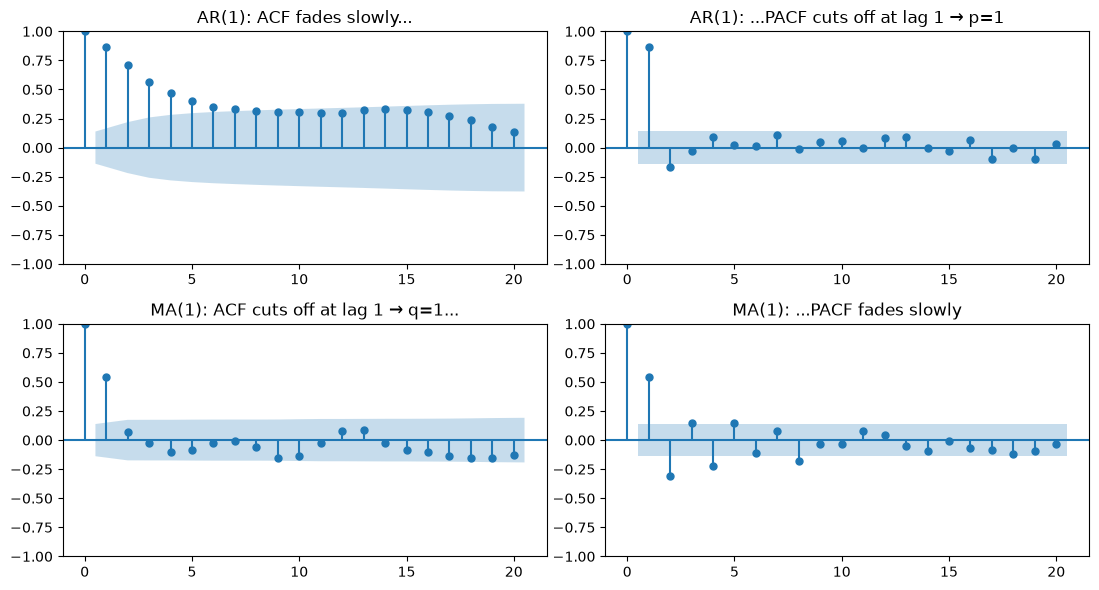

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
plot_acf(ar_strong, ax=axes[0, 0], lags=20, title="AR(1): ACF fades slowly...")
plot_pacf(ar_strong, ax=axes[0, 1], lags=20, title="AR(1): ...PACF cuts off at lag 1 → p=1")
plot_acf(ma1, ax=axes[1, 0], lags=20, title="MA(1): ACF cuts off at lag 1 → q=1...")
plot_pacf(ma1, ax=axes[1, 1], lags=20, title="MA(1): ...PACF fades slowly")
plt.tight_layout(); plt.show()

---

## 4. ARIMA(p, d, q): the full recipe

**ARIMA = difference the series `d` times, then fit ARMA(p, q) on the result.**

| Letter | Meaning | Question it answers |
|--------|---------|---------------------|
| **p** | AR order | How many past *values* matter? |
| **d** | differencing | How many times to difference until stationary? |
| **q** | MA order | How many past *shocks* matter? |

We already know `d = 1` for our airline data (the ADF test told us).
Now look at the fingerprints of the **differenced** series:

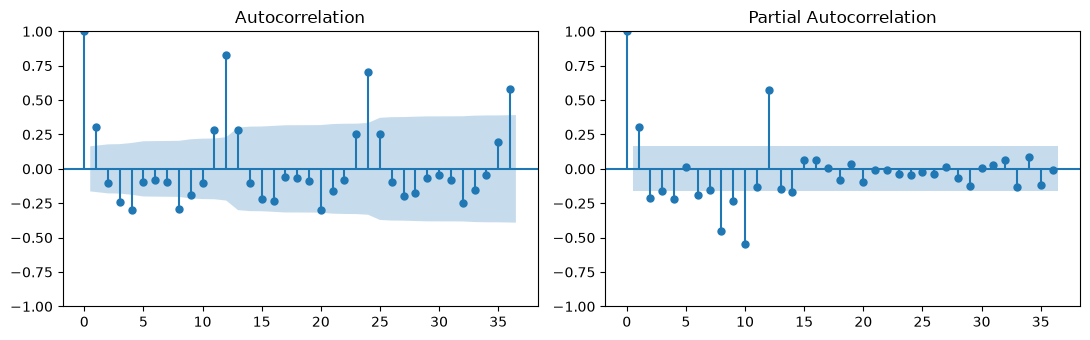

In [14]:
y_diff = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(y_diff, ax=axes[0], lags=36)
plot_pacf(y_diff, ax=axes[1], lags=36)
plt.tight_layout(); plt.show()

🎯 **Your turn (chat):** Based on these plots, propose an `(p, d, q)`.
There is no single right answer — real fingerprints are messy. Also: what do you
notice about lags **12, 24, 36** in the ACF? (Hold that thought.)

Let's settle the debate with a **bake-off**. The judge is **AIC**
(Akaike Information Criterion): a score that rewards a good fit but *penalizes*
extra parameters, to punish overfitting. **Lower AIC = better.** Add your proposed
orders to the list:

In [15]:
from statsmodels.tsa.arima.model import ARIMA

candidates = [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 2)]  # ← add yours here

print(f"{'order':>12s} {'AIC':>10s}")
for order in candidates:
    aic = ARIMA(y, order=order).fit().aic
    print(f"{str(order):>12s} {aic:>10.1f}")

       order        AIC
   (0, 1, 0)     1413.9
   (0, 1, 1)     1397.3
   (1, 1, 0)     1401.9
   (1, 1, 1)     1394.7
   (2, 1, 2)     1353.3


c:\Training\Week 3\Practice\TimeSeries\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2,1,2) wins the bake-off. Time to earn our salary: **train on 1949–1958,
forecast 1959–1960**, and compare against what actually happened.

Train: 120 months | Test (held out): 24 months


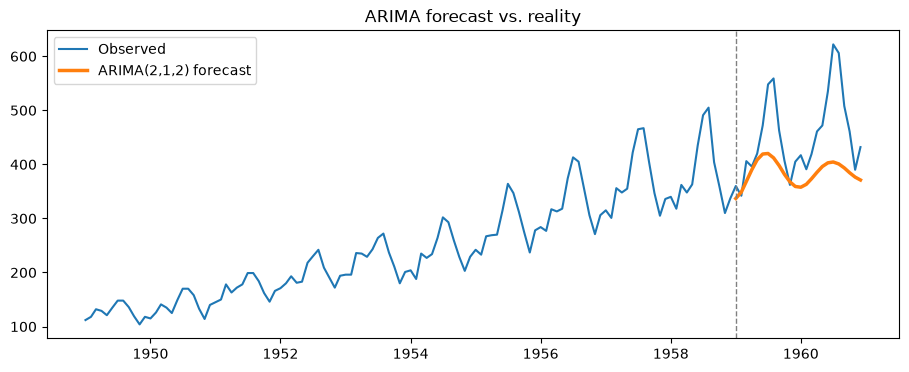

MAPE: 13.8%  (Mean Absolute Percentage Error — avg % miss)


In [16]:
train, test = y[:"1958-12"], y["1959-01":]
print(f"Train: {len(train)} months | Test (held out): {len(test)} months")

arima_fc = ARIMA(train, order=(2, 1, 2)).fit().forecast(len(test))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y, color=C_OBS, label="Observed")
ax.plot(arima_fc, color=C_ARIMA, lw=2.5, label="ARIMA(2,1,2) forecast")
ax.axvline(test.index[0], color="gray", ls="--", lw=1)
ax.set_title("ARIMA forecast vs. reality")
ax.legend()
plt.show()

mape = lambda actual, pred: float(np.mean(np.abs((actual - pred) / actual)) * 100)
print(f"MAPE: {mape(test, arima_fc):.1f}%  (Mean Absolute Percentage Error — avg % miss)")

🎯 **Your turn (chat):** The forecast follows the trend but something is badly wrong.
**What is it, and why did it happen?**

<details><summary>Reveal</summary>

The forecast is **blind to seasonality** — no summer peaks, no winter dips. ARIMA only
looks a few lags back, but the seasonal pattern lives **12 lags back**. That's what the
ACF spikes at lags 12, 24, 36 were shouting at us.

If you shipped this, the airline would park empty planes in July and turn away
customers in December. We need a model that looks one *season* back — enter SARIMA.
</details>

---

## 5. SARIMA: ARIMA that understands seasons

**SARIMA(p, d, q)(P, D, Q, m)** = your ARIMA, plus a second ARIMA that operates at
**seasonal lags**:

| Part | Meaning |
|------|---------|
| (p, d, q) | the ARIMA you already know — month-to-month behavior |
| **m** | season length — 12 for monthly data with a yearly cycle |
| **P** | AR on seasonal lags — does *last July* predict *this July*? |
| **D** | seasonal differencing — subtract the value from one season ago |
| **Q** | MA on seasonal lags — do *last year's* shocks still echo? |

A sensible default starting point in practice: **(1,1,1)(1,1,1,m)** — then tune.

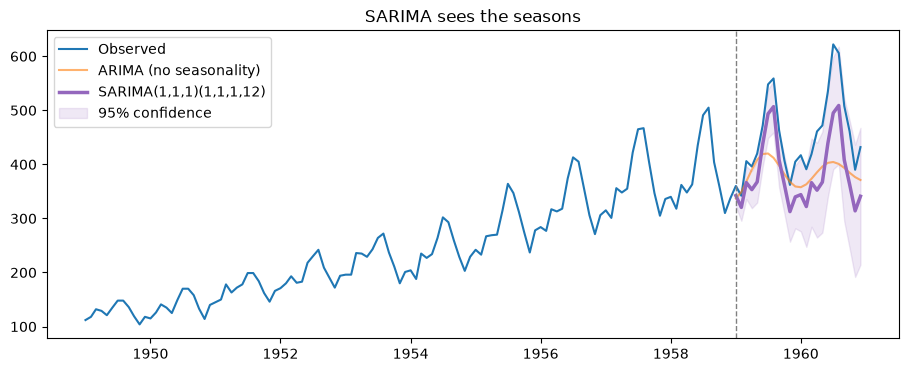

ARIMA  MAPE: 13.8%
SARIMA MAPE: 14.7%


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
pred = sarima.get_forecast(len(test))
sarima_fc, ci = pred.predicted_mean, pred.conf_int()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y, color=C_OBS, label="Observed")
ax.plot(arima_fc, color=C_ARIMA, lw=1.5, alpha=0.6, label="ARIMA (no seasonality)")
ax.plot(sarima_fc, color=C_SARIMA, lw=2.5, label="SARIMA(1,1,1)(1,1,1,12)")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color=C_SARIMA, alpha=0.15,
                label="95% confidence")
ax.axvline(test.index[0], color="gray", ls="--", lw=1)
ax.set_title("SARIMA sees the seasons")
ax.legend()
plt.show()

print(f"ARIMA  MAPE: {mape(test, arima_fc):.1f}%")
print(f"SARIMA MAPE: {mape(test, sarima_fc):.1f}%")

First applied-engineering lesson: **always report the confidence band, not just the
line.** The business decision for "450k ± 20k" is very different from "450k ± 200k".
A forecast without uncertainty is a guess wearing a suit.

But wait —

🎯 **Your turn (chat):** SARIMA clearly has the **right shape**, yet its MAPE is no
better than ARIMA's. Something is still wrong. Look back at the *three patterns*
from minute one. **Which one have we still not handled?**

<details><summary>Reveal</summary>

**The growing swings.** Each summer peak is *bigger* than the last — the seasonality
multiplies with the level. Our model adds a fixed-size seasonal wave, so it
increasingly under-shoots the peaks and over-shoots the dips, and MAPE punishes it.

The standard fix is one line: model **`log(y)`** instead of `y`, then convert back
with `exp()`. The log turns "grows by 10% each year" into "grows by a constant" —
exactly the world the model assumes. Watch what happens to the score:
</details>

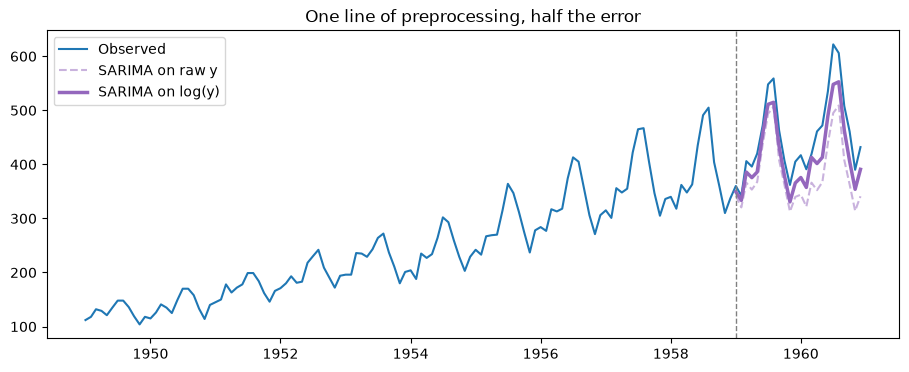

ARIMA          MAPE: 13.8%
SARIMA         MAPE: 14.7%
SARIMA + log   MAPE: 7.8%


In [18]:
log_model = SARIMAX(np.log(train), order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
log_fc = np.exp(log_model.forecast(len(test)))   # back to passenger units

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y, color=C_OBS, label="Observed")
ax.plot(sarima_fc, color=C_SARIMA, lw=1.5, ls="--", alpha=0.5, label="SARIMA on raw y")
ax.plot(log_fc, color=C_SARIMA, lw=2.5, label="SARIMA on log(y)")
ax.axvline(test.index[0], color="gray", ls="--", lw=1)
ax.set_title("One line of preprocessing, half the error")
ax.legend()
plt.show()

print(f"ARIMA          MAPE: {mape(test, arima_fc):.1f}%")
print(f"SARIMA         MAPE: {mape(test, sarima_fc):.1f}%")
print(f"SARIMA + log   MAPE: {mape(test, log_fc):.1f}%")

Error cut nearly in half — by *understanding the data*, not by a fancier model.
This is the difference between someone who calls `.fit()` and an applied engineer.

---

🎯 **Your turn — the Forecast Challenge (5 min).** The instructor's model scores
**7.8% MAPE**. Beat it. Call `evaluate()` with any orders you like — best score in
the chat wins bragging rights. (A better combination exists. Find it.)

In [19]:
def evaluate(order, seasonal_order=(0, 0, 0, 0), use_log=False):
    """Train on 1949-1958, score on held-out 1959-1960. Lower MAPE wins."""
    t = np.log(train) if use_log else train
    model = SARIMAX(t, order=order, seasonal_order=seasonal_order).fit(disp=False)
    fc = model.forecast(len(test))
    if use_log:
        fc = np.exp(fc)
    rmse = float(np.sqrt(np.mean((test - fc) ** 2)))
    print(f"SARIMA{order}x{seasonal_order} log={use_log!s:<5}  "
          f"RMSE={rmse:6.1f}  MAPE={mape(test, fc):5.1f}%")

# Instructor's baseline — beat this:
evaluate((1, 1, 1), (1, 1, 1, 12), use_log=True)

# Your attempts:
# evaluate((0, 1, 1), (0, 1, 1, 12), use_log=True)

SARIMA(1, 1, 1)x(1, 1, 1, 12) log=True   RMSE=  39.9  MAPE=  7.8%


### Trust, but verify: residual diagnostics

A good model's **residuals** (the errors it leaves behind) should be pure noise —
no pattern left to learn. If residuals still show structure, the model missed something.

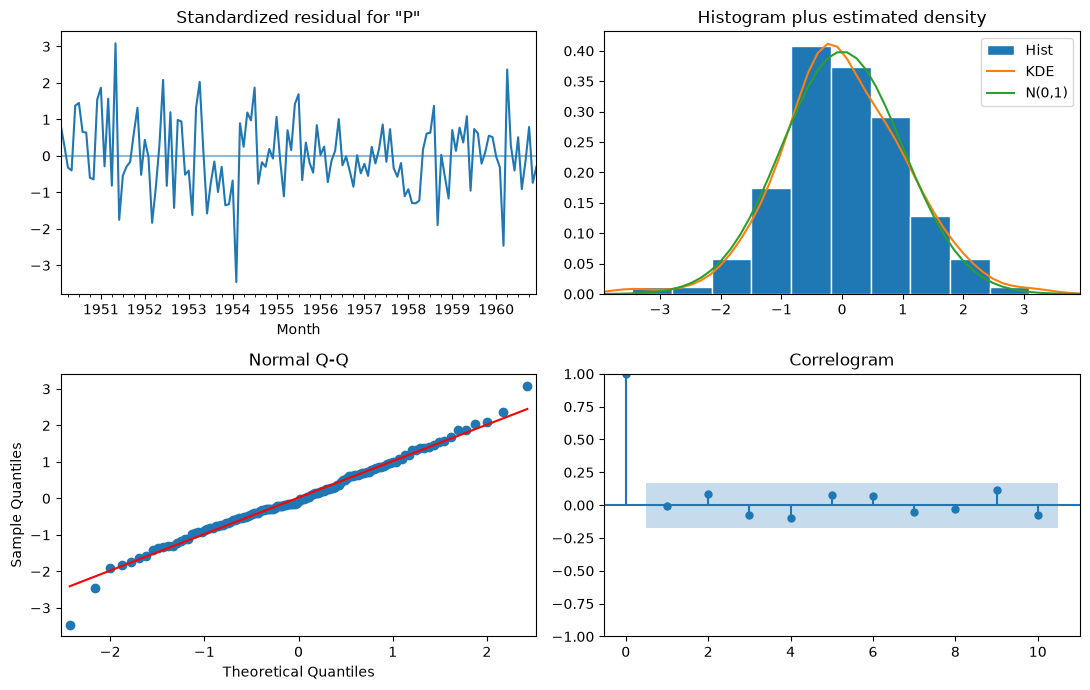

In [20]:
final = SARIMAX(np.log(y), order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
fig = final.plot_diagnostics(figsize=(11, 7))
plt.tight_layout(); plt.show()

How to read the four panels — a 30-second checklist:

- **Standardized residuals** (top-left): no visible pattern? ✅
- **Histogram** (top-right): roughly bell-shaped? ✅
- **Q-Q plot** (bottom-left): dots hug the red line? ✅
- **Correlogram** (bottom-right): all bars inside the band? ✅ Nothing left to learn.

Finally, retrain on **all** the data and save the model to a file. This file is the
handoff between the data scientist and the engineer — which is the next part of the session.

In [22]:
import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(final, "models/sarima_airline.pkl")
print("Saved models/sarima_airline.pkl")
print("Sanity check — next 3 months:", [round(v) for v in np.exp(final.forecast(3))])

Saved models/sarima_airline.pkl
Sanity check — next 3 months: [451, 427, 482]


---

## 6. From notebook to production

Your model lives in a notebook on your laptop. The airline's booking website, the
mobile app, and the finance team's dashboard all need forecasts. **They will not
open your notebook.**

The industry-standard answer: wrap the model in a **web API** — a URL that any
program can call and get JSON back. We'll build one with **FastAPI** in about
20 lines of code.

➡️ **Switch to the `02_fastapi/` folder** — see `README.md` for the run commands.

## Learn more

- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice* — free at [otexts.com/fpp3](https://otexts.com/fpp3/)
- `pmdarima.auto_arima` — automates the (p,d,q)(P,D,Q,m) search you did by hand today
- FastAPI docs — [fastapi.tiangolo.com](https://fastapi.tiangolo.com/) (some of the best docs in software)